# Tutorial Denoising

> denoising


In [ ]:
#| default_exp tutorial_denoising

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.losses import SSIMLoss
from bioMONAI.metrics import *
from bioMONAI.datasets import download_file


In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
# Specify the directory where you want to save the downloaded files
output_directory = "../_data/U2OS"
# Define the base URL for the dataset
url = 'http://csbdeep.bioimagecomputing.com/example_data/snr_7_binning_2.zip'

# Download only the first two images
download_file(url, output_directory, extract=True)

The file has been downloaded and saved to: ../_data/U2OS
Decompression (if needed) has been handled automatically.


### Create Dataloader

In [ ]:
X_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/low/'

bs = 16
patch_size = 128

itemTfms = [RandCropND(patch_size), RandRot90(prob=.75), RandFlip(prob=0.75)]
batchTfms = [ScaleIntensityPercentiles()]

get_target_fn = get_target('GT', same_filename=True, relative_path=True)

data = BioDataLoaders.from_folder(
    X_path, 
    get_target_fn, 
    valid_pct=0.05, 
    seed=42, 
    item_tfms=itemTfms,
    batch_tfms=batchTfms, 
    show_summary=False,
    bs = bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 2335 
validation images: 122


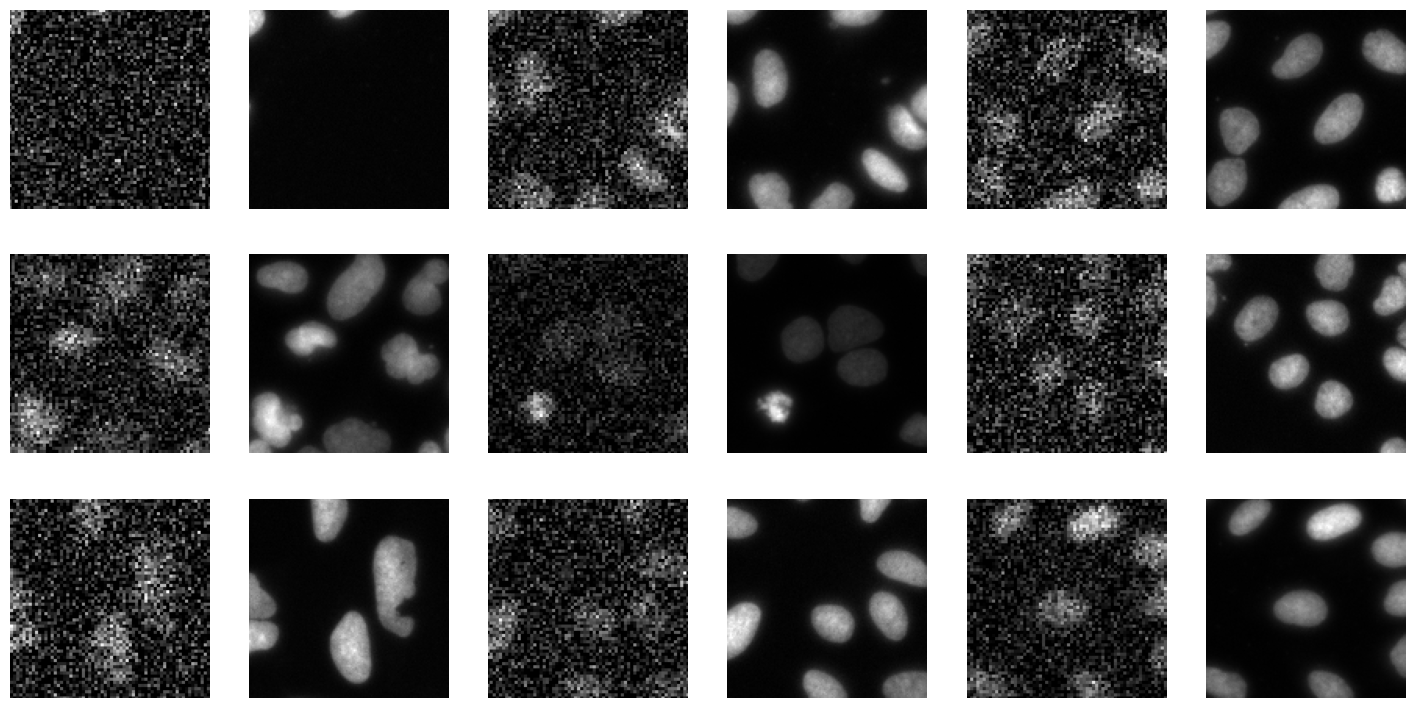

In [ ]:
data.show_batch()

### Load and train a 2D model

In [ ]:
from bioMONAI.nets import create_unet_model, resnet34

model = create_unet_model(resnet34, 1, (128,128), True, n_in=1, cut=7)


In [ ]:
loss = CombinedLoss(mse_weight=0.8, mae_weight=0.1)

metrics = [MSEMetric(), MAEMetric(), SSIMMetric(2)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)


epoch,train_loss,valid_loss,MSE,MAE,SSIM,time
0,0.054948,0.033524,0.002847,0.027113,0.808813,00:06
1,0.032904,0.028185,0.002278,0.024341,0.839718,00:06
2,0.027547,0.024597,0.001872,0.022441,0.860341,00:06


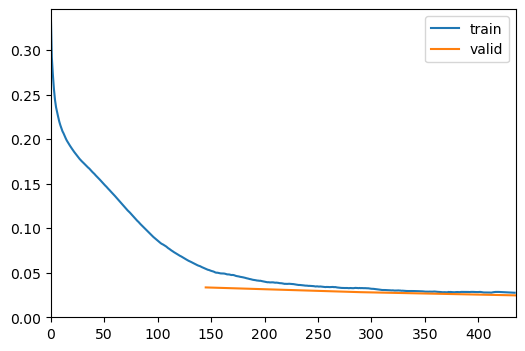

epoch,train_loss,valid_loss,MSE,MAE,SSIM,time
0,0.021998,0.021451,0.001554,0.020205,0.878232,00:06
1,0.021067,0.022689,0.001724,0.020902,0.871300,00:06
2,0.020592,0.021527,0.001441,0.019367,0.876606,00:06
3,0.021190,0.024113,0.002141,0.023390,0.865544,00:06
4,0.021828,0.023220,0.001921,0.022387,0.869733,00:06
5,0.021300,0.021483,0.001392,0.019110,0.876478,00:07
6,0.020816,0.024373,0.002176,0.023649,0.864158,00:07
7,0.020993,0.020773,0.001286,0.018436,0.880234,00:07
8,0.020302,0.022379,0.001356,0.018964,0.870229,00:06
9,0.019343,0.022373,0.001665,0.020283,0.872694,00:06


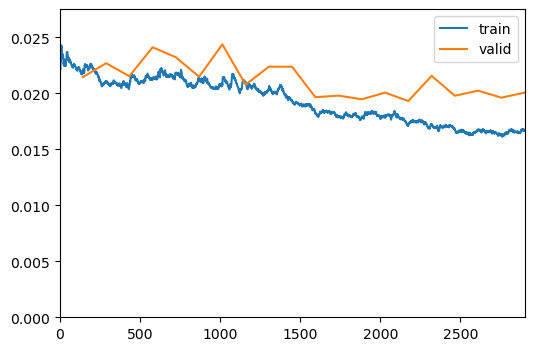

In [ ]:
trainer.fine_tune(20, freeze_epochs=2)

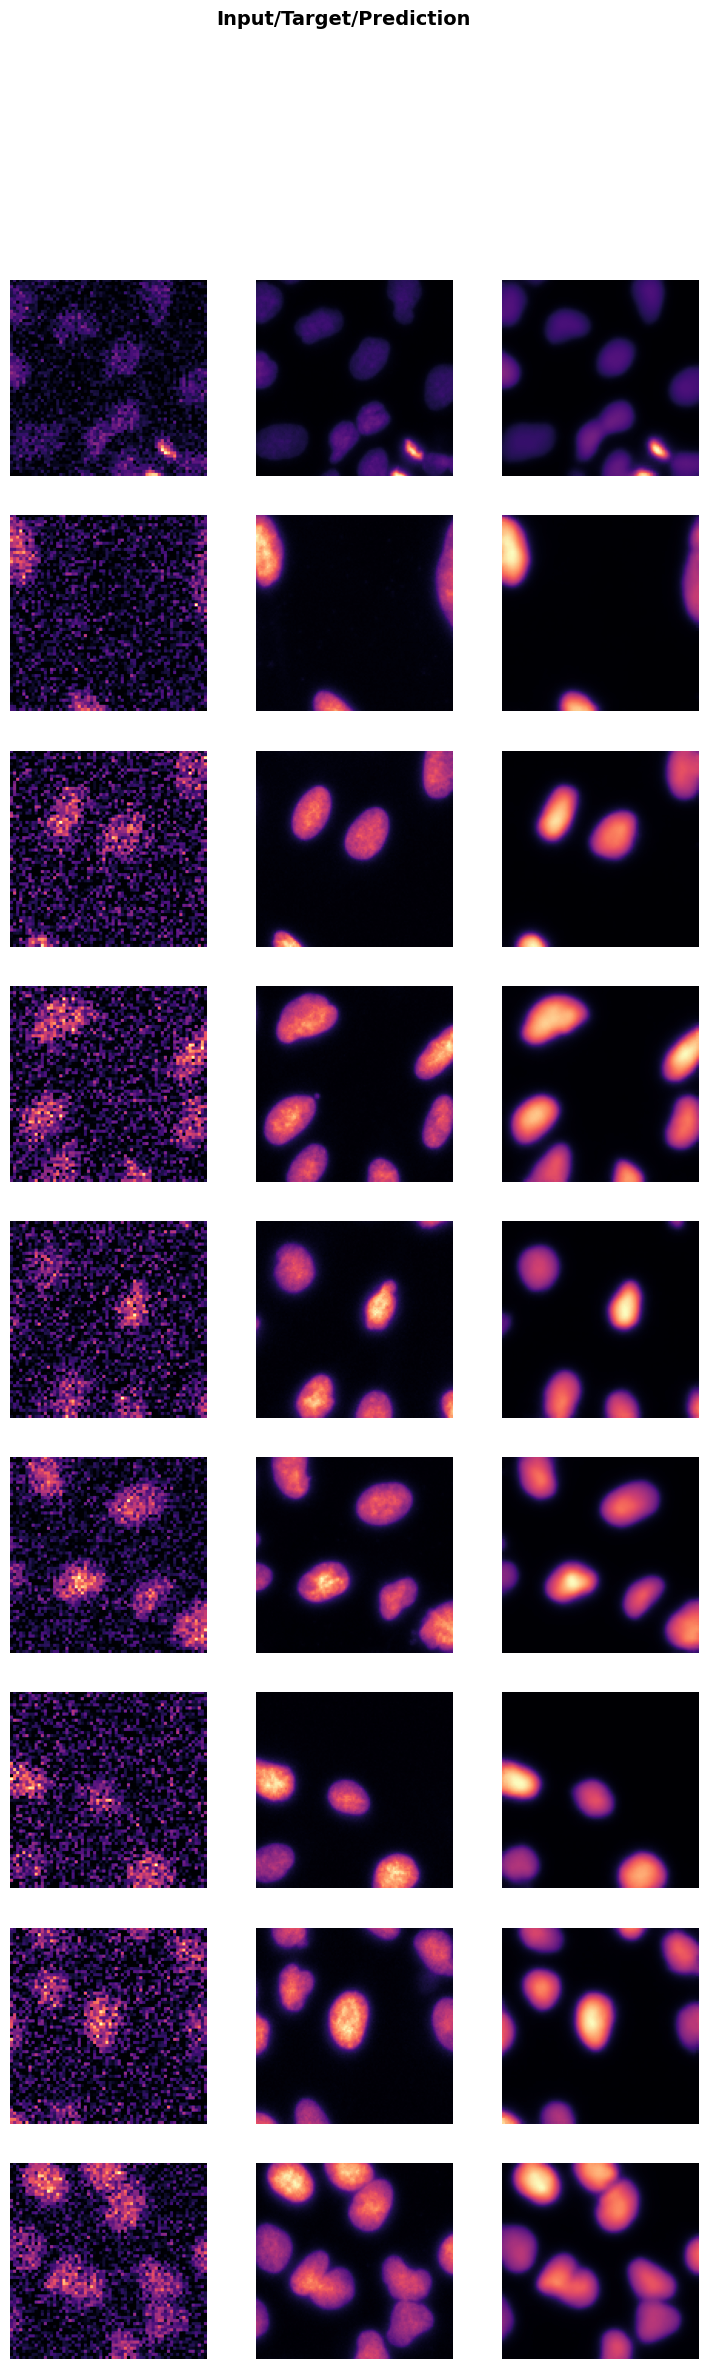

In [ ]:
trainer.show_results(cmap='magma')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

In [ ]:
test_X_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/test/low/'

test_data = data.test_dl(get_image_files(test_X_path), with_labels=True)


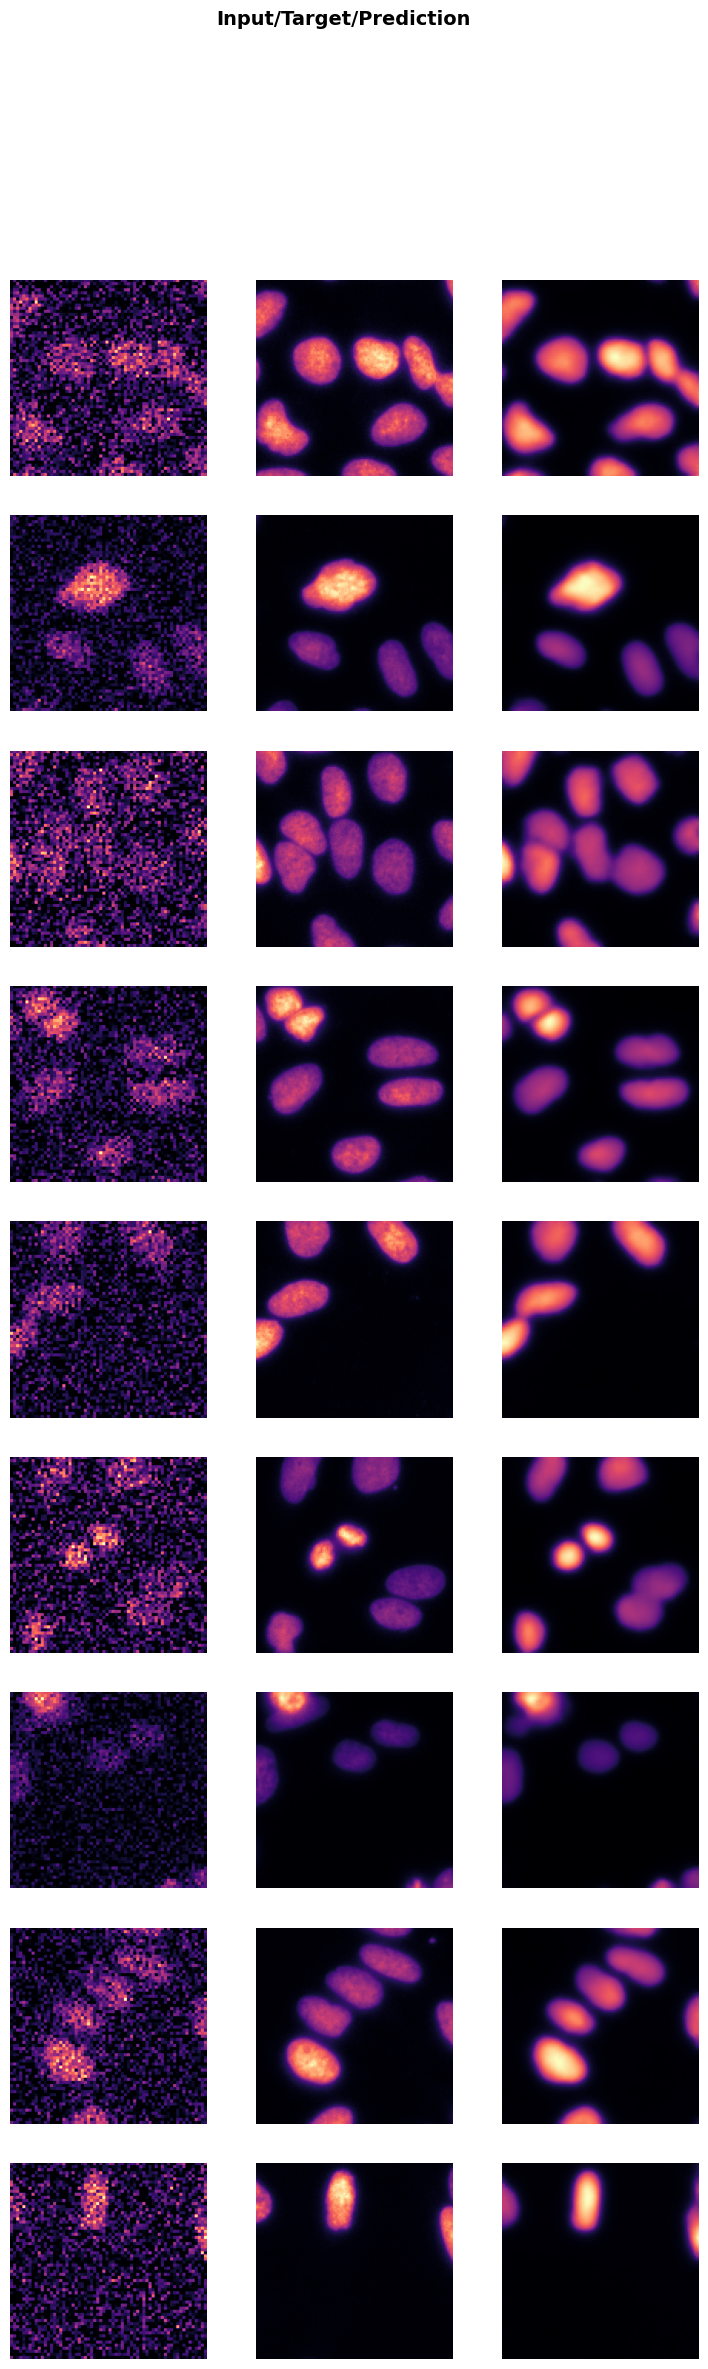

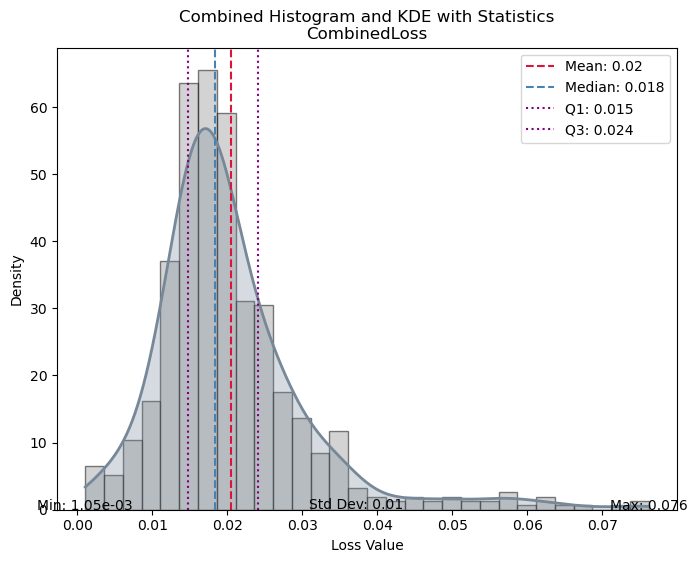

,Value
CombinedLoss,
Mean,0.020478
Median,0.018410
Standard Deviation,0.010467
Min,0.001048
Max,0.076200
Q1,0.014772
Q3,0.024101


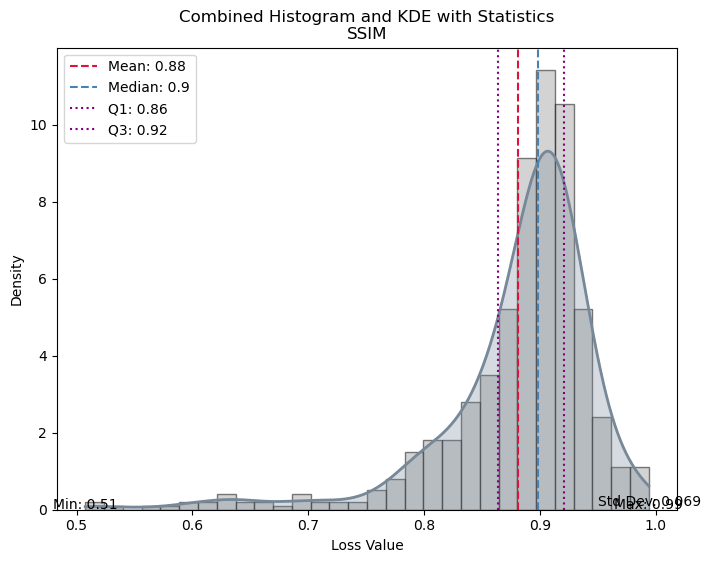

,Value
SSIM,
Mean,0.881417
Median,0.898649
Standard Deviation,0.068538
Min,0.507372
Max,0.994053
Q1,0.864136
Q3,0.920404


In [ ]:
evaluate_model(trainer, test_data, loss, SSIMMetric(2), show_graph=True, show_table=True);